# Module 6

### Part 1


Aggregating tornado data into a monthly count (just for Illinois thankfully!)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime

# for the model
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, root_mean_squared_error

In [2]:
# Reading in the dataset
data = pd.read_csv("1950-2021_actual_tornadoes.csv")

data

,om,yr,mo,dy,date,time,tz,st,stf,stn,...,len,wid,ns,sn,sg,f1,f2,f3,f4,fc
0,192,1950,10,1,1950-10-01,21:00:00,3,OK,40,23,...,15.80,10,1,1,1,25,0,0,0,0
1,193,1950,10,9,1950-10-09,02:15:00,3,NC,37,9,...,2.00,880,1,1,1,47,0,0,0,0
2,195,1950,11,20,1950-11-20,02:20:00,3,KY,21,1,...,0.10,10,1,1,1,177,0,0,0,0
3,196,1950,11,20,1950-11-20,04:00:00,3,KY,21,2,...,0.10,10,1,1,1,209,0,0,0,0
4,197,1950,11,20,1950-11-20,07:30:00,3,MS,28,14,...,2.00,37,1,1,1,101,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67553,620523,2021,9,8,2021-09-08,15:32:00,3,PA,42,0,...,0.73,30,1,1,1,109,0,0,0,0
67554,620524,2021,9,8,2021-09-08,15:35:00,3,PA,42,0,...,1.45,30,1,1,1,109,0,0,0,0
67555,620525,2021,9,8,2021-09-08,19:08:00,3,FL,12,0,...,1.45,50,1,1,1,129,0,0,0,0
67556,620526,2021,9,9,2021-09-09,02:10:00,3,CT,9,0,...,0.75,75,1,1,1,13,0,0,0,0


In [3]:
# Grabbing just the Illinois data
data_IL = data[data['st'] == "IL"]

# Aggregating it into monthly counts
IL_monthly = data_IL.groupby(['yr', 'mo']).size().reset_index(name='count')

# Adding back in the date index for the merge with the climate indices below
IL_monthly['date'] = pd.to_datetime(dict(year=IL_monthly.yr, month=IL_monthly.mo, day=1))
IL_monthly = IL_monthly.set_index('date')
# Quick check - looks good!
IL_monthly

,yr,mo,count
date,,,
1950-01-01,1950,1,2
1950-03-01,1950,3,1
1950-06-01,1950,6,1
1950-07-01,1950,7,1
1950-12-01,1950,12,3
...,...,...,...
2021-06-01,2021,6,15
2021-07-01,2021,7,8
2021-08-01,2021,8,16


### Part 2

In [4]:
# Using the code from M04N01 to get the climate indices
enso = pd.read_csv('https://www.esrl.noaa.gov/psd/data/correlation/censo.data',sep=r'\s+',header=None,skiprows=1,skipfooter=2, engine='python')
pdo = pd.read_csv('https://www.ncei.noaa.gov/pub/data/cmb/ersst/v5/index/ersst.v5.pdo.dat',sep=r'\s+',header=None,skiprows=2, engine='python')
nao = pd.read_csv('https://www.cpc.ncep.noaa.gov/products/precip/CWlink/pna/norm.nao.monthly.b5001.current.ascii.table',sep=r'\s+',header=None,skiprows=1, engine='python')
ao = pd.read_csv('https://www.cpc.ncep.noaa.gov/products/precip/CWlink/daily_ao_index/monthly.ao.index.b50.current.ascii.table',sep=r'\s+',header=None,skiprows=1, engine='python')

enso_new=pd.DataFrame()
nao_new=pd.DataFrame()
pdo_new=pd.DataFrame()
ao_new=pd.DataFrame()

enso_new['Date']=pd.date_range(start=datetime.datetime(enso[0].iloc[0],1,1),end=datetime.datetime(enso[0].iloc[-1],12,1),freq="MS")
nao_new['Date'] = pd.date_range(start=datetime.datetime(nao[0].iloc[0],1,1),end=datetime.datetime(nao[0].iloc[-1],12,1),freq="MS")
pdo_new['Date'] = pd.date_range(start=datetime.datetime(pdo[0].iloc[0],1,1),end=datetime.datetime(pdo[0].iloc[-1],12,1),freq="MS")
ao_new['Date'] = pd.date_range(start=datetime.datetime(ao[0].iloc[0],1,1),end=datetime.datetime(ao[0].iloc[-1],12,1),freq="MS")

enso_new = enso_new.set_index('Date')
nao_new = nao_new.set_index('Date')
pdo_new = pdo_new.set_index('Date')
ao_new = ao_new.set_index('Date')

enso_new['ENSO']=enso.loc[:,1:].stack(dropna=False).values
nao_new['NAO']=nao.loc[:,1:].stack(dropna=False).values
pdo_new['PDO']=pdo.loc[:,1:].stack(dropna=False).values
ao_new['AO']=ao.loc[:,1:].stack(dropna=False).values

C:\Users\macdonaldc\AppData\Local\Temp\ipykernel_18656\1273979846.py:22: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  enso_new['ENSO']=enso.loc[:,1:].stack(dropna=False).values
C:\Users\macdonaldc\AppData\Local\Temp\ipykernel_18656\1273979846.py:23: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  nao_new['NAO']=nao.loc[:,1:].stack(dropna=False).values
C:\Users\macdonaldc\AppData\Local\Temp\ipykernel_18656\1273979846.py:24: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pand

In [5]:
# Merging the indices and addressing the nan values
newdf_all = pd.merge(enso_new,pdo_new, left_index=True, right_index=True)

newdf_all.loc[newdf_all['ENSO'] <= -9.9,'ENSO'] = np.nan
newdf_all.loc[newdf_all['PDO'] > 90.,'PDO'] = np.nan
newdf_all = pd.merge(newdf_all,nao_new, left_index=True, right_index=True)
newdf_all.loc[newdf_all['NAO'] <= -99.9,'NAO'] = np.nan
newdf_all = pd.merge(newdf_all,ao_new, left_index=True, right_index=True)
newdf_all.loc[newdf_all['AO'] <= -99.9,'AO'] = np.nan

newdf_all


,ENSO,PDO,NAO,AO
Date,,,,
1950-01-01,-0.67,-1.61,0.92,-0.060
1950-02-01,-1.52,-2.17,0.40,0.627
1950-03-01,-1.37,-1.89,-0.36,-0.008
1950-04-01,-1.31,-1.99,0.73,0.555
1950-05-01,-1.26,-3.19,-0.59,0.072
...,...,...,...,...
2025-08-01,-0.38,-3.20,0.26,0.036
2025-09-01,NaN,-2.33,-0.80,0.048
2025-10-01,NaN,-2.40,-0.96,0.064


In [6]:
# Merging with the tornado dataset
IL_monthly_indices = pd.merge(IL_monthly, newdf_all, left_index=True, right_index=True)
IL_monthly_indices

,yr,mo,count,ENSO,PDO,NAO,AO
1950-01-01,1950,1,2,-0.67,-1.61,0.92,-0.060
1950-03-01,1950,3,1,-1.37,-1.89,-0.36,-0.008
1950-06-01,1950,6,1,-1.79,-2.52,-0.06,0.539
1950-07-01,1950,7,1,-1.72,-3.65,-1.26,-0.802
1950-12-01,1950,12,3,-1.42,-1.06,-1.02,-1.928
...,...,...,...,...,...,...,...
2021-06-01,2021,6,15,-0.23,-1.82,0.77,0.845
2021-07-01,2021,7,8,-1.12,-2.00,0.03,0.630
2021-08-01,2021,8,16,-0.70,-0.95,-0.28,-0.209
2021-10-01,2021,10,10,-0.96,-3.13,-2.29,-0.146


### Part 3

Making a Random Forest Regression model

In [7]:
# Creating the test, train data

X_indices = IL_monthly_indices[["ENSO","PDO","NAO","AO"]]
Y_tornados = IL_monthly_indices["count"]

X_train, X_test, Y_train, Y_test = train_test_split(X_indices, Y_tornados,
                                                test_size=0.30, random_state=1)

# Instantiating the model
model = RandomForestRegressor(random_state=1)

# Fitting the model
model.fit(X_train, Y_train)

# Generating predicitons
Y_train_pred = model.predict(X_train) 
Y_test_pred = model.predict(X_test)

# Printing stats for both training and test predictions
print("Training Data R2 = ", r2_score(Y_train,Y_train_pred))
print("Training Data RMSE = ", root_mean_squared_error(Y_train,Y_train_pred))
print("Test Data R2 = ", r2_score(Y_test,Y_test_pred))
print("Test Data RMSE = ", root_mean_squared_error(Y_test,Y_test_pred))

# Just noticing that the question asks for R not R2
r_training = np.corrcoef(Y_train, Y_train_pred)
r_test = np.corrcoef(Y_test, Y_test_pred)
print("Training Data R = ", r_training[0,1])
print("Test Data R = ",  r_test[0,1])


Training Data R2 =  0.8308552815488321
Training Data RMSE =  3.37761307678411
Test Data R2 =  -0.15119134109195875
Test Data RMSE =  9.348399815181079
Training Data R =  0.9684207278410935
Test Data R =  -0.004776785548705255


The training data has an alright R2 and RMSE, but the Test data performs quite poorly, with a low R2 and higher RMSE

Text(0.5, 1.0, 'Observed vs Predicted tornado count (RFR)')

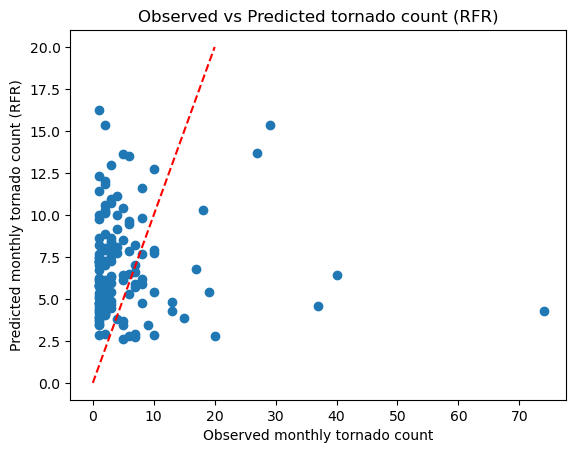

In [15]:
# Making a scatter plot of the results
plt.scatter(Y_test, Y_test_pred)
plt.plot([0,20,20],[0,20,20],'r--')
plt.xlabel("Observed monthly tornado count")
plt.ylabel("Predicted monthly tornado count (RFR)")
plt.title("Observed vs Predicted tornado count (RFR)")

### Part 4
Creating a one-hot encoding

In [9]:
from sklearn.preprocessing import OneHotEncoder

encoding = OneHotEncoder(sparse_output = False)

encoded_months = encoding.fit_transform(IL_monthly_indices[["mo"]])
encoded_months

array([[1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 0., ..., 0., 0., 1.]], shape=(445, 12))

In [10]:
monthly_columns = encoding.get_feature_names_out(["mo"])
IL_monthly_indices_encoded = pd.DataFrame(encoded_months, columns = monthly_columns, index=IL_monthly_indices.index)
IL_monthly_indices_encoded

,mo_1,mo_2,mo_3,mo_4,mo_5,mo_6,mo_7,mo_8,mo_9,mo_10,mo_11,mo_12
1950-01-01,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1950-03-01,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1950-06-01,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1950-07-01,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1950-12-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
2021-06-01,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2021-07-01,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2021-08-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2021-10-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [20]:
# Making a new dataframe with the indices values
X_OH = pd.concat([IL_monthly_indices[["ENSO","PDO","NAO","AO"]], IL_monthly_indices_encoded], axis=1)
# Quick check
#X_test_OH

In [22]:
# Making the test-train split for the OH
X_train_OH , X_test_OH, Y_train_OH, Y_test_OH = train_test_split(X_OH, Y_tornados,
                                                test_size=0.30, random_state=1)
# Specifying the model
model_OH = RandomForestRegressor(random_state=1)

# Fitting the model
model_OH.fit(X_train_OH, Y_train_OH)

# Predicting test values
Y_test_pred_OH = model_OH.predict(X_test_OH)

In [24]:
# Printing stats for OH
print("OH R2 = ", r2_score(Y_test_OH,Y_test_pred_OH))
print("OH RMSE = ", root_mean_squared_error(Y_test_OH,Y_test_pred_OH))

# Correl for OH
r_OH = np.corrcoef(Y_test_OH,Y_test_pred_OH)
print("OH R = ", r_OH[0,1])

OH R2 =  0.012301963278577355
OH RMSE =  8.659157045940942
OH R =  0.2732394027573529


Text(0.5, 1.0, 'Observed vs Predicted tornado count (OH RFR)')

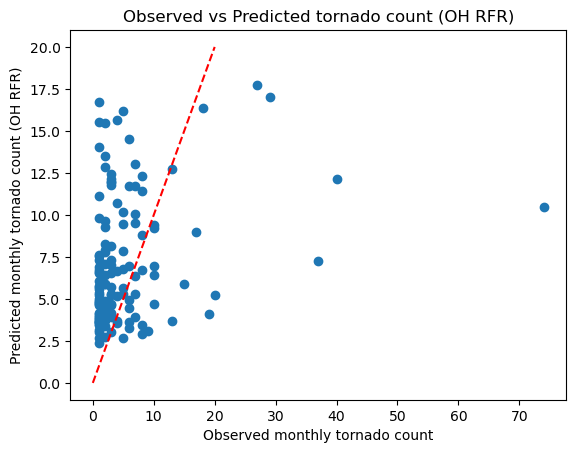

In [27]:
# Making a scatter plot of the results
plt.scatter(Y_test_OH, Y_test_pred_OH)
plt.plot([0,20,20],[0,20,20],'r--')
plt.xlabel("Observed monthly tornado count")
plt.ylabel("Predicted monthly tornado count (OH RFR)")
plt.title("Observed vs Predicted tornado count (OH RFR)")

### Part 5

Assessing feature importance, once for the RFR and once for the OH RFR

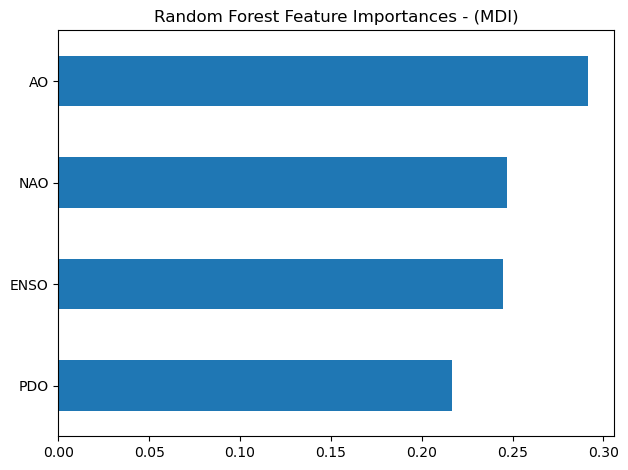

In [38]:
# Feature importances
mdi_importances = pd.Series(
    model.feature_importances_, index=X_indices.columns
).sort_values(ascending=True)

# Plotting importances
ax = mdi_importances.plot.barh()
ax.set_title("Random Forest Feature Importances - (MDI)")
ax.figure.tight_layout()

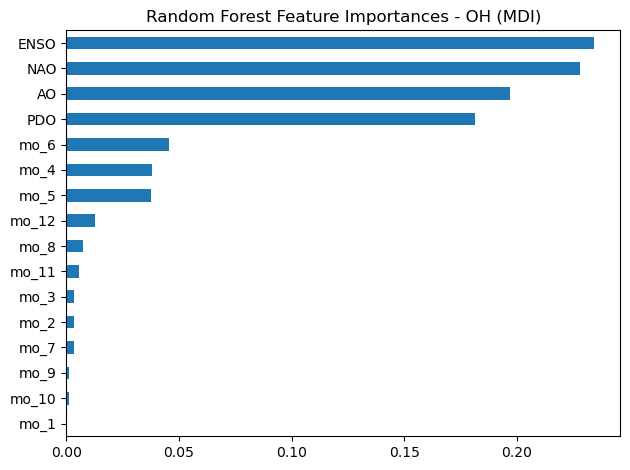

In [39]:
# Feature importances - OH
mdi_importances = pd.Series(
    model_OH.feature_importances_, index=X_OH.columns
).sort_values(ascending=True)

# Plotting importances - OH
ax = mdi_importances.plot.barh()
ax.set_title("Random Forest Feature Importances - OH (MDI)")
ax.figure.tight_layout()

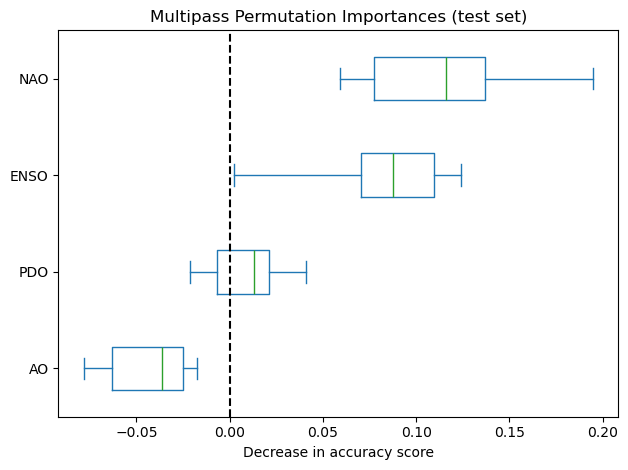

In [30]:
# Permutation importance
from sklearn.inspection import permutation_importance

result = permutation_importance(
    model, X_test, Y_test, n_repeats=10, random_state=42, n_jobs=2
)

sorted_importances_idx = result.importances_mean.argsort()
importances = pd.DataFrame(
    result.importances[sorted_importances_idx].T,
    columns=X_indices.columns[sorted_importances_idx],
)

# Plotting the permutation importances
ax = importances.plot.box(vert=False, whis=10)
ax.set_title("Multipass Permutation Importances (test set)")
ax.axvline(x=0, color="k", linestyle="--")
ax.set_xlabel("Decrease in accuracy score")
ax.figure.tight_layout()

It looks like NAO is the most important feature followed by ENSO. AO shows the opposite trend when looking at mean decrease in impurity as in the permutation importance graph. It seems like going off the permutation importance graph, AO is actually just adding noise. PDO is relatively unimportant in both.

### Part 6

Creating a SHAP summary plot

In [40]:
import shap
shap.initjs()

# Set up of epxlainers
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test)


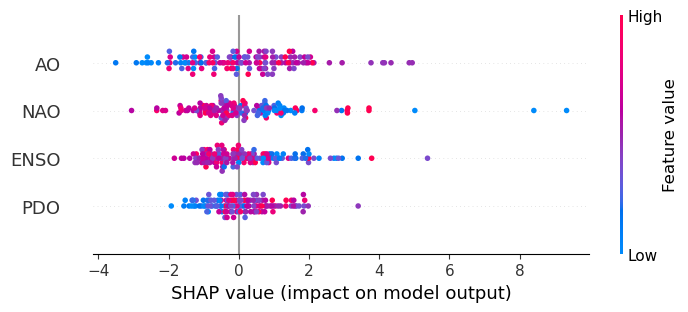

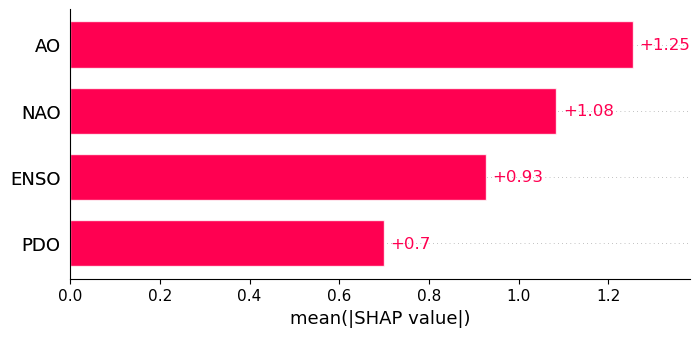

In [32]:
# Crating a beeswarm and bar chart
shap.plots.beeswarm(shap_values, max_display=12)
shap.plots.bar(shap_values, max_display=12)

Here it seems like AO has a much wider spread, which means it's more important for predicting the value of an individual feature. It's possible that with the wider spread, it shows that there is an increase in the amount of variance, but that it's not necessarily improving the model accuracy. It seems like this confirms that it's adding noise to the model. 

### Part 7

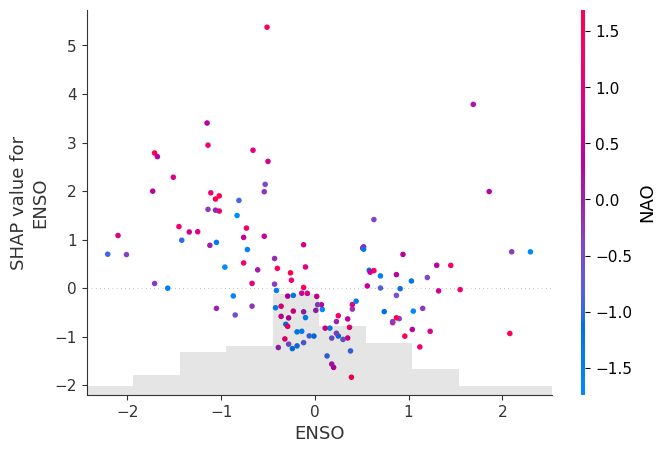

In [41]:
shap.plots.scatter(shap_values[:, 'ENSO'], color=shap_values)

It seems like lower and higher values of ENSO lead to more tornadoes, especially when there are higher values of NAO.

### Part 8

Bringing all the observations above together, it looks like NAO is the most important feature followed by ENSO. PDO doesn't seem to add or take away much from the model. AO has a more complex relationship. It has a high MDI and a high SHAP, but a low permutation omportance. It seems like it may actually just be adding noise, even if it's a stronger predictor of individual values. It would probably be best to drop AO if I was going to make the model again. PDO seems to be relatively unimportant.

Month also seems to be an important contributor, with tornadoes more likely to occur in Apr-Jun, but less important than any of the index values.

It seems like lower and higher values of ENSO lead to more tornadoes, especially when there are higher values of NAO, so there may be some other interesting interplays between the indices that weren't tested for.